In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

import numpy as np

In [2]:
# Dataset taken directly from Keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Print shapes

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


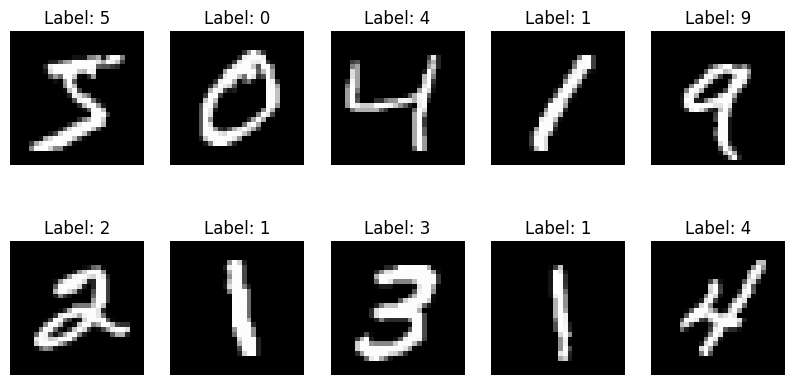

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i], cmap='gray')

    plt.title(f"Label: {y_train[i]}")

    plt.axis('off')

plt.show()

In [4]:
# Convert pixel values from 0-255 to 0-1

x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
model = keras.Sequential([

    # Convert 28x28 image into a single vector
    layers.Flatten(input_shape=(28, 28)),

    # Hidden Layer 1
    layers.Dense(128, activation='relu'),

    # Dropout Layer
    layers.Dropout(0.2),

    # Hidden Layer 2
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

# Show model architecture

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [7]:
history = model.fit(

    x_train,
    y_train,

    epochs=10,

    batch_size=32,

    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9094 - loss: 0.3077 - val_accuracy: 0.9645 - val_loss: 0.1167
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9548 - loss: 0.1460 - val_accuracy: 0.9745 - val_loss: 0.0880
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9654 - loss: 0.1105 - val_accuracy: 0.9790 - val_loss: 0.0740
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9711 - loss: 0.0916 - val_accuracy: 0.9797 - val_loss: 0.0722
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9741 - loss: 0.0819 - val_accuracy: 0.9777 - val_loss: 0.0769
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9764 - loss: 0.0717 - val_accuracy: 0.9780 - val_loss: 0.0763
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9784 - loss: 0.0661 - val_accuracy: 0.9798 - val_loss: 0.0742
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9803 - loss: 0

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0733
Test Accuracy: 0.9789000153541565


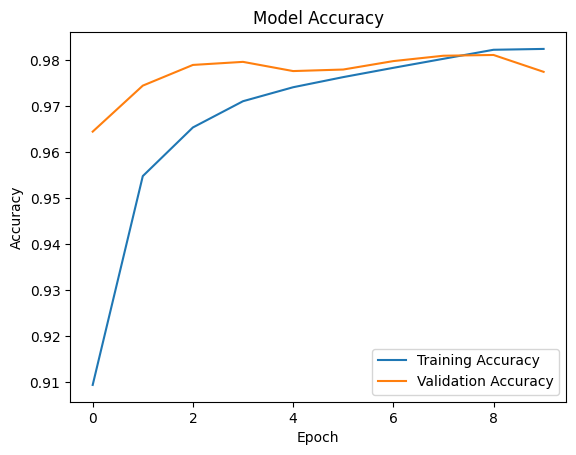

In [9]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

In [10]:
predictions = model.predict(x_test)

# Predict first image

predicted_label = np.argmax(predictions[0])

print("Predicted Digit:", predicted_label)

print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Digit: 7
Actual Digit: 7


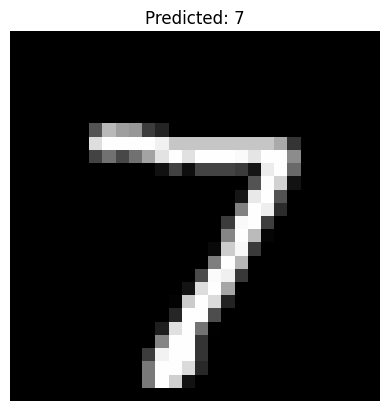

In [11]:
plt.imshow(x_test[0], cmap='gray')

plt.title(f"Predicted: {predicted_label}")

plt.axis('off')

plt.show()